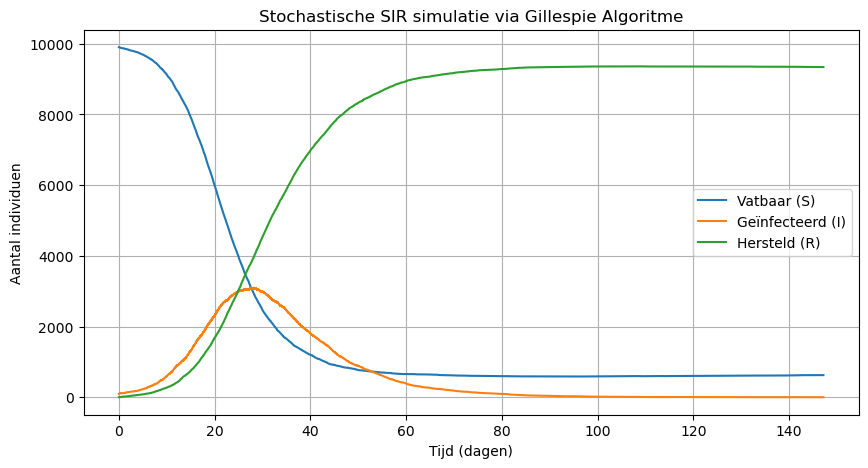

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Stochastic Model

def gillespie_sir(N, beta, gamma, mu, X0, Y0, Z0, t_max):
    # Initiële waarden
    t = 0.0
    X, Y, Z = X0, Y0, Z0
    
    # Lijsten voor de resultaten
    times = [t]
    X_history = [X]
    Y_history = [Y]
    Z_history = [Z]
    
    while t < t_max and Y > 0:
        # Bereken de rates (propensities) van elke gebeurtenis
        r1 = mu * N                  # Geboorte (X -> X + 1)
        r2 = beta * X * Y / N        # Infectie (X -> X-1, Y -> Y+1)
        r3 = gamma * Y               # Herstel (Y -> Y-1, Z -> Z+1)
        r4 = mu * X                  # Sterfte S (X -> X - 1)
        r5 = mu * Y                  # Sterfte I (Y -> Y - 1)
        r6 = mu * Z                  # Sterfte R (Z -> Z - 1)
        
        rates = [r1, r2, r3, r4, r5, r6]
        R_total = sum(rates)
        
        if R_total == 0:
            break
            
        # 1. Bepaal de tijd tot de volgende gebeurtenis (Exponentiële verdeling)
        u1 = np.random.uniform(0, 1)
        dt = -np.log(u1) / R_total
        t += dt
        
        # 2. Bepaal welke gebeurtenis plaatsvindt
        u2 = np.random.uniform(0, 1)
        probabilities = [r / R_total for r in rates]
        event = np.random.choice(6, p=probabilities)
        
        # 3. Voer de gekozen gebeurtenis uit
        if event == 0:    # Geboorte
            X += 1
        elif event == 1:  # Infectie
            X -= 1
            Y += 1
        elif event == 2:  # Herstel
            Y -= 1
            Z += 1
        elif event == 3:  # Sterfte X
            X -= 1
        elif event == 4:  # Sterfte Y
            Y -= 1
        elif event == 5:  # Sterfte Z
            Z -= 1
            
        # Bewaar de toestand
        times.append(t)
        X_history.append(X)
        Y_history.append(Y)
        Z_history.append(Z)
        
    return np.array(times), np.array(X_history), np.array(Y_history), np.array(Z_history)

# Voorbeeld van een simulatie run:
N = 10000
R0 = 3.0
gamma = 1/10  
beta = R0 * gamma
mu = 0.0001   

X0, Y0, Z0 = 9900, 100, 0
t_max = 365

times, X, Y, Z = gillespie_sir(N, beta, gamma, mu, X0, Y0, Z0, t_max)

# Plotten
plt.figure(figsize=(10, 5))
plt.plot(times, X, label='Vatbaar (S)')
plt.plot(times, Y, label='Geïnfecteerd (I)')
plt.plot(times, Z, label='Hersteld (R)')
plt.xlabel('Tijd (dagen)')
plt.ylabel('Aantal individuen')
plt.title('Stochastische SIR simulatie via Gillespie Algoritme')
plt.legend()
plt.grid(True)
plt.show()

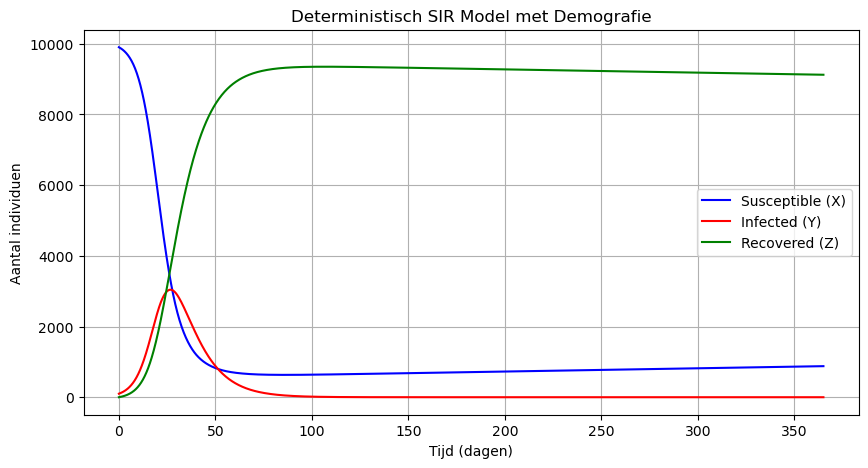

In [ ]:
# Deterministic Model

from scipy.integrate import solve_ivp

def sir_deterministic(t, y, N, beta, gamma, mu):
    X, Y, Z = y
    
    # Differential equations for absolute numbers X, Y, Z
    dX_dt = mu * N - (beta * X * Y / N) - mu * X
    dY_dt = (beta * X * Y / N) - gamma * Y - mu * Y
    dZ_dt = gamma * Y - mu * Z
    
    return [dX_dt, dY_dt, dZ_dt]

# Model parameters
N = 10000        
beta = 0.3      
gamma = 0.1     
mu = 0.0001      

# Initiële aantallen (X0 + Y0 + Z0 = N)
X0 = 9900
Y0 = 100
Z0 = 0
y0 = [X0, Y0, Z0]

# Tijdsdomein
t_span = (0, 365)
t_eval = np.linspace(t_span[0], t_span[1], 2000)

# Oplossen van de ODE
solution = solve_ivp(
    sir_deterministic, 
    t_span, 
    y0, 
    args=(N, beta, gamma, mu), 
    t_eval=t_eval
)

# Plotten
plt.figure(figsize=(10, 5))
plt.plot(solution.t, solution.y[0], label='Susceptible (X)', color='blue')
plt.plot(solution.t, solution.y[1], label='Infected (Y)', color='red')
plt.plot(solution.t, solution.y[2], label='Recovered (Z)', color='green')
plt.title('Deterministisch SIR Model met Demografie')
plt.xlabel('Tijd (dagen)')
plt.ylabel('Aantal individuen')
plt.legend()
plt.grid(True)
plt.show()

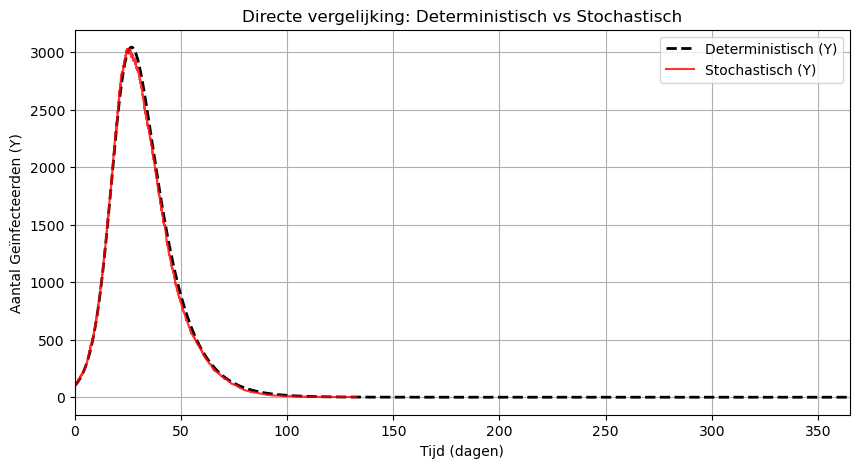

In [ ]:
# De 2 modellen samen plotten

# Parameters die exact gelijk zijn voor beide modellen:
N = 10000
beta = 0.3
gamma = 0.1
mu = 0.0001

X0, Y0, Z0 = 9900, 100, 0
t_max = 365  

# 1. Deterministische oplossing
t_eval = np.linspace(0, t_max, 1000)
sol = solve_ivp(sir_deterministic, (0, t_max), [X0, Y0, Z0], args=(N, beta, gamma, mu), t_eval=t_eval)

# 2. Stochastische oplossing (Gillespie)
t_gillespie, X_g, Y_g, Z_g = gillespie_sir(N, beta, gamma, mu, X0, Y0, Z0, t_max)

# 3. Plotten in één figuur
plt.figure(figsize=(10, 5))

# Deterministisch
plt.plot(sol.t, sol.y[1], color='black', linewidth=2, linestyle='--', label='Deterministisch (Y)')

# Stochastisch
plt.plot(t_gillespie, Y_g, color='red', alpha=0.8, label='Stochastisch (Y)')

plt.xlim(0, t_max)
plt.xlabel('Tijd (dagen)')
plt.ylabel('Aantal Geïnfecteerden (Y)')
plt.title('Directe vergelijking: Deterministisch vs Stochastisch')
plt.legend()
plt.grid(True)
plt.show()

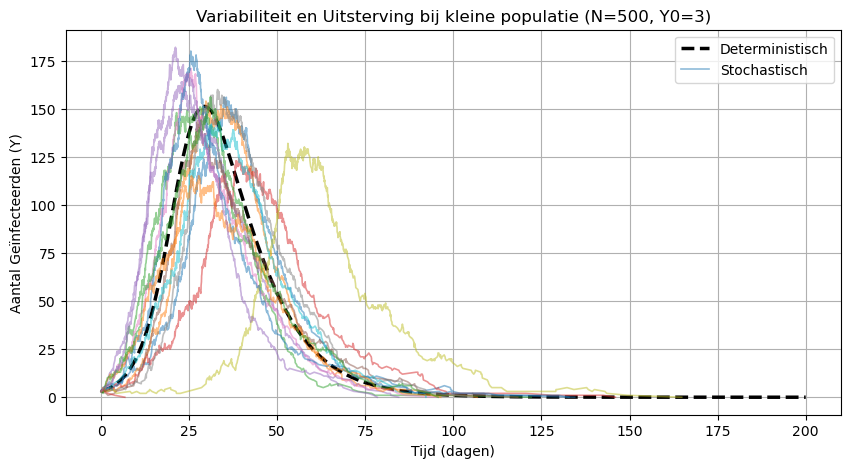

In [ ]:
# Simulatie met kleinere populatie N
N = 500
beta = 0.3
gamma = 0.1
mu = 0.0001
X0, Y0, Z0 = 497, 3, 0  
t_max = 200

# Plot deterministisch
t_eval = np.linspace(0, t_max, 1000)
sol = solve_ivp(sir_deterministic, (0, t_max), [X0, Y0, Z0], args=(N, beta, gamma, mu), t_eval=t_eval)

plt.figure(figsize=(10, 5))
plt.plot(sol.t, sol.y[1], color='black', linewidth=2.5, linestyle='--', label='Deterministisch')

# Plot meerdere stochastische runs
for i in range(15):
    t_gillespie, X_g, Y_g, Z_g = gillespie_sir(N, beta, gamma, mu, X0, Y0, Z0, t_max)
    plt.plot(t_gillespie, Y_g, alpha=0.5, linewidth=1.2, label='Stochastisch' if i == 0 else "")

plt.xlabel('Tijd (dagen)')
plt.ylabel('Aantal Geïnfecteerden (Y)')
plt.title('Variabiliteit en Uitsterving bij kleine populatie (N=500, Y0=3)')
plt.legend()
plt.grid(True)
plt.show()